# Introduction to Agents with LangGraph

## Context

LangChain simplifies LLM application development, especially for agents that automate tasks.

While agents offer exciting possibilities, building reliable systems is challenging. To provide more control for production-ready agents, [LangGraph](https://langchain-ai.github.io/langgraph/) was developed as a separate framework. It enables precise control over agent workflows, like forcing specific tool calls or adapting prompts based on state.

## Initial Setup

In [1]:
# !uv pip install langchain_tavily
## You also need to set up the Tavily API Key

In [2]:
import os, getpass
from dotenv import load_dotenv 
load_dotenv(override=True)

True

In [3]:
#Check for Groq API Key
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ API Key: ")

## Chat Models

In [4]:
from langchain.chat_models import init_chat_model

model_name = "openai/gpt-oss-120b"
llm = init_chat_model(model_name, model_provider="groq") #Other Llama alternatives available are llama3-8b-8192, llama-3.3-70b-versatile

## Search Tools

[Tavily](https://tavily.com/) is a search engine designed for LLMs and RAG that provides efficient, fast, and consistent search results. It's simple to sign up for and includes a generous free tier. 

In [5]:
#Check for Tavily API Key
if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY API Key: ")

In [6]:
from langchain_tavily import TavilySearch
tavily_search = TavilySearch(max_results=3)
search_docs = tavily_search.invoke("What is the weather in Ulwe today?")

In [7]:
search_docs

{'query': 'What is the weather in Ulwe today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Weather in Ulwe, Navi Mumbai',
   'url': 'https://www.weatherapi.com/',
   'content': "{'location': {'name': 'Mumbai', 'region': 'Maharashtra', 'country': 'India', 'lat': 18.975, 'lon': 72.8258, 'tz_id': 'Asia/Kolkata', 'localtime_epoch': 1790048100, 'localtime': '2026-09-22 09:05'}, 'current': {'last_updated_epoch': 1790047800, 'last_updated': '2026-09-22 09:00', 'temp_c': 27.3, 'temp_f': 81.2, 'is_day': 1, 'condition': {'text': 'Patchy rain nearby', 'icon': '//cdn.weatherapi.com/weather/64x64/day/176.png', 'code': 1063}, 'wind_mph': 4.3, 'wind_kph': 6.8, 'wind_degree': 166, 'wind_dir': 'SSE', 'pressure_mb': 1011.0, 'pressure_in': 29.85, 'precip_mm': 0.01, 'precip_in': 0.0, 'humidity': 81, 'cloud': 87, 'feelslike_c': 30.6, 'feelslike_f': 87.1, 'windchill_c': 27.3, 'windchill_f': 81.2, 'heatindex_c': 31.1, 'heatindex_f': 88.0, 'dewpoint_c': 23.8, 'dewpoi

# Agent

## Review

We built a router.

* Our chat model will decide to make a tool call or not based upon the user input
* We use a conditional edge to route to a node that will call our tool or simply end

![Screenshot 2024-08-21 at 12.44.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac0ba0bd34b541c448cc_agent1.png)

## Goals

Now, we can extend this into a generic agent architecture.

In the above router, we invoked the model and, if it chose to call a tool, we returned a `ToolMessage` to the user.
 
But, what if we simply pass that `ToolMessage` *back to the model*?

We can let it either (1) call another tool or (2) respond directly.

This is the intuition behind [ReAct](https://react-lm.github.io/), a general agent architecture.
  
* `act` - let the model call specific tools 
* `observe` - pass the tool output back to the model 
* `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

This [general purpose architecture](https://blog.langchain.dev/planning-for-agents/) can be applied to many types of tools. 

![Screenshot 2024-08-21 at 12.45.43 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac0b4a2c1e5e02f3e78b_agent2.png)

In [8]:
tools = [tavily_search]

# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# play around with it and see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

Let's create our LLM and prompt it with the overall desired agent behavior.

In [9]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing web-based research.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

As before, we use `MessagesState` and define a `Tools` node with our list of tools.

The `Assistant` node is just our model with bound tools.

We create a graph with `Assistant` and `Tools` nodes.

We add `tools_condition` edge, which routes to `End` or to `Tools` based on  whether the `Assistant` calls a tool.

Now, we add one new step:

We connect the `Tools` node *back* to the `Assistant`, forming a loop.

* After the `assistant` node executes, `tools_condition` checks if the model's output is a tool call.
* If it is a tool call, the flow is directed to the `tools` node.
* The `tools` node connects back to `assistant`.
* This loop continues as long as the model decides to call tools.
* If the model response is not a tool call, the flow is directed to END, terminating the process.

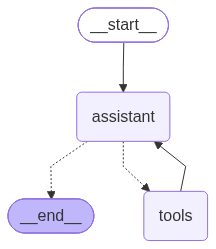

In [10]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [11]:
messages_input = [HumanMessage(content="Tell me about Jio Institute AI program")]
messages_output = react_graph.invoke({"messages": messages_input})

In [13]:
for m in messages_output['messages']:
    m.pretty_print()

================================ Human Message =================================

Tell me about Jio Institute AI program
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_83d98d9e-2ca1-47ae-a637-a5d83e97f406)
 Call ID: fc_83d98d9e-2ca1-47ae-a637-a5d83e97f406
  Args:
    query: Jio Institute AI program
    search_depth: advanced
    time_range: year
================================= Tool Message =================================
Name: tavily_search

{"query": "Jio Institute AI program", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=jW1uwM2M4Ws", "title": "FREE AI Course by Jio Institute – Certificate + Pro Ai tools access | Seats Filling Fast", "content": "# FREE AI Course by Jio Institute – Certificate + Pro Ai tools access | Seats Filling Fast\n## Channel: Gemba Gyan (verified)\n180K subscribers\n1.7K likes\n\n### Description\n70,860 views\nPosted: 2026-08-0

# Agent memory

## Review

Previously, we built an agent that can:

* `act` - let the model call specific tools 
* `observe` - pass the tool output back to the model 
* `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

![Screenshot 2024-08-21 at 12.45.32 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab7453080e6802cd1703_agent-memory1.png)

## Goals

Now, we're going extend our agent by introducing memory.

In [14]:
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing web-based research.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

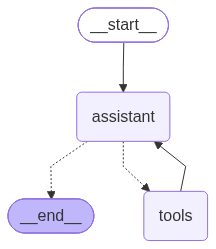

In [15]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

## Memory

Let's run our agent, as before.

In [ ]:
messages = [HumanMessage(content="How is AI program at Jio Institute?")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

Now, let's multiply by 2!

In [ ]:
messages = [HumanMessage(content="Tell me more about the institute's faculty.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================

I’m not sure which number you’d like to multiply by 2. Could you please provide the value you want to use?


We don't retain memory of 7 from our initial chat!

This is because [state is transient](https://github.com/langchain-ai/langgraph/discussions/352#discussioncomment-9291220) to a single graph execution.

Of course, this limits our ability to have multi-turn conversations with interruptions. 

We can use [persistence](https://langchain-ai.github.io/langgraph/how-tos/persistence/) to address this! 

LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update. 

One of the easiest checkpointers to use is the `MemorySaver`, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

When we use memory, we need to specify a `thread_id`.

This `thread_id` will store our collection of graph states.

Here is a cartoon:

* The checkpointer write the state at every step of the graph
* These checkpoints are saved in a thread 
* We can access that thread in the future using the `thread_id`

![state.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e0e9f526b41a4ed9e2d28b_agent-memory2.png)


In [ ]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content="How is AI program at Jio Institute?")]

# Run
messages = react_graph_memory.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (fc_3d425720-b213-497a-b0ea-ded60bcf6281)
 Call ID: fc_3d425720-b213-497a-b0ea-ded60bcf6281
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.


If we pass the same `thread_id`, then we can proceed from from the previously logged state checkpoint! 

In this case, the above conversation is captured in the thread.

The `HumanMessage` we pass (`"Multiply that by 2."`) is appended to the above conversation.

So, the model now know that `that` refers to the `The sum of 3 and 4 is 7.`.

In [ ]:
messages = [HumanMessage(content="Tell me more about the institute's faculty.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (fc_3d425720-b213-497a-b0ea-ded60bcf6281)
 Call ID: fc_3d425720-b213-497a-b0ea-ded60bcf6281
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_200ade3d-0281-48b9-8ef1-4c777ee42b58)
 Call ID: fc_200ade3d-0281-48b9-8ef1-4c777ee42b58
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message =============

# Using Pre-built Agent

## Defining the Search Tool

In [ ]:
from langchain_tavily import TavilySearch

search = TavilySearch(max_results=10)
search_results = search.invoke("what is the weather in Ulwe?")
print(search_results)
# If we want, we can create other tools.
# Once we have all the tools we want, we can put them in a list that we will reference later.
tools = [search]

{'query': 'what is the weather in SF', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.easeweather.com/north-america/united-states/california/city-and-county-of-san-francisco/september', 'title': 'September 2026 Weather - City and County of San Francisco', 'content': 'Until now, September 2026 in City and County of San Francisco has been nearly identical to the historical average, with a temperature of 20.4 °F (showing only a slight deviation of 0.2 °F).\n The forecast for the next days in City and County of San Francisco predicts temperatures to be around 18 °F, close to the historical average. [...] | 20 Weather Alert Overcast 16° | 21 Patchy rain possible 17° | 22 Sunny 18° | 23 Overcast 19° | 24 Overcast 18° | 25 Overcast 16° | 26 Sunny 18° |\n| 27 Sunny 23° | 28 Sunny 25° | 29 Sunny 19° | 30 Partly cloudy 17° | [...] | Sept. 25 | Overcast Overcast | 16° /14° | 0 mm | 5 |\n| Sept. 26 | Sunny Sunny | 18° /14° | 0 mm | 5 |\n| Sept. 27 | Sun

## Creating the Agent

In [ ]:
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(llm, tools)

In [ ]:
tools

[TavilySearch(max_results=10, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))]

## Running the Agent

In [ ]:
response = agent_executor.invoke({"messages": [HumanMessage(content="hi! I am Anant")]})

response["messages"]

[HumanMessage(content='hi! I am Anant', additional_kwargs={}, response_metadata={}, id='e048d6ea-5c67-41e0-b179-535b58aac45c'),
 AIMessage(content='Hi Anant! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says hi and introduces themselves. We can greet back and ask how we can help. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 321, 'total_tokens': 377, 'completion_time': 0.11680916, 'prompt_time': 0.017377799, 'queue_time': 0.909812005, 'total_time': 0.134186959, 'completion_tokens_details': {'reasoning_tokens': 29}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--5d16d541-1427-414a-81d4-03bc8b7e5ed9-0', usage_metadata={'input_tokens': 321, 'output_tokens': 56, 'total_tokens': 377})]

In [ ]:
response = agent_executor.invoke(
    {"messages": [HumanMessage(content="Who am I?")]}
)
response["messages"]

[HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='9e880c50-3b9a-420c-8e35-875923d92eed'),
 AIMessage(content='I’m not able to identify you based on our conversation so far. If you’d like to share a bit about yourself—or let me know what you’re looking for—I’ll do my best to help!', additional_kwargs={'reasoning_content': 'The user asks "Who am I?" This is ambiguous. As ChatGPT, we don\'t have personal info. Should respond that I don\'t know, ask for clarification.'}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 319, 'total_tokens': 403, 'completion_time': 0.176831965, 'prompt_time': 0.017918169, 'queue_time': 0.210612387, 'total_time': 0.194750134, 'completion_tokens_details': {'reasoning_tokens': 34}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6dedd2be22', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--869de42c-b1b5-46ad-99ef-5b480cf5ec37-0', usage_metadata={'input_

## Adding in Memory

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [ ]:
agent_executor = create_react_agent(llm, tools, checkpointer=memory)
config = {"configurable": {"thread_id": "abc123"}}

In [ ]:
response = agent_executor.invoke({"messages": [HumanMessage(content="hi I am Anant!")]},config)

response["messages"]

[HumanMessage(content='hi I am Anant!', additional_kwargs={}, response_metadata={}, id='ce64d551-3183-40c0-ac63-8edcefb56c79'),
 AIMessage(content='Hi Anant! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi I am Anant!" Likely a greeting. Should respond friendly. No need to use tools.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 321, 'total_tokens': 372, 'completion_time': 0.115278785, 'prompt_time': 0.014743304, 'queue_time': 0.348238773, 'total_time': 0.130022089, 'completion_tokens_details': {'reasoning_tokens': 26}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--2fc501c9-673a-4498-8ba3-2daf23eabd6a-0', usage_metadata={'input_tokens': 321, 'output_tokens': 51, 'total_tokens': 372})]

In [ ]:
response = agent_executor.invoke({"messages": [HumanMessage(content="What's my name!")]},config)

response["messages"]

[HumanMessage(content='hi I am Anant!', additional_kwargs={}, response_metadata={}, id='ce64d551-3183-40c0-ac63-8edcefb56c79'),
 AIMessage(content='Hi Anant! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi I am Anant!" Likely a greeting. Should respond friendly. No need to use tools.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 321, 'total_tokens': 372, 'completion_time': 0.115278785, 'prompt_time': 0.014743304, 'queue_time': 0.348238773, 'total_time': 0.130022089, 'completion_tokens_details': {'reasoning_tokens': 26}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--2fc501c9-673a-4498-8ba3-2daf23eabd6a-0', usage_metadata={'input_tokens': 321, 'output_tokens': 51, 'total_tokens': 372}),
 HumanMessage(content="What's my name!", additional_kwargs={}, response_metadata={}, id='f64b603a-ec82